In [2]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()

In [3]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [24]:
# load the data
sigma_mi = pickle.load(open(os.path.join(DATA_PATH, "optimal_noise_data_2026-07-27.pkl"), "rb"))
sigma_mi = pd.DataFrame(sigma_mi)
sigma_mi["limit"] = sigma_mi["limit"].round(2)

# compute the optimal noise for each limit
sigma_mi["optimal_noise"] = sigma_mi.groupby("limit")["mi"].transform("idxmax")
sigma_mi["optimal_noise"] = sigma_mi.loc[sigma_mi["optimal_noise"], "sigma"].values
sigma_mi.head()



,sigma,limit,mi,H_y,H_y_given_A,optimal_noise
0,0.0001,0.01,0.709920,-3.912023,-4.621943,0.000643
1,0.0001,0.25,0.694545,-0.693147,-1.387692,0.018307
2,0.0001,0.50,0.693925,0.000000,-0.693925,0.031993
3,0.0001,0.75,0.693696,0.405465,-0.288231,0.055908
4,0.0001,1.00,0.693575,0.693147,-0.000428,0.067342


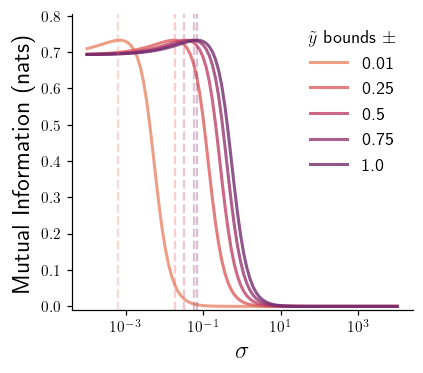

In [ ]:
# preliminary figure
flare_pal = sns.color_palette("flare", len(sigma_mi["limit"].unique()))
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=110)

ax.set_xscale("log", base=10)
sns.lineplot(data=sigma_mi, x='sigma', y='mi', hue='limit', ax=ax, lw=2, alpha=0.8, palette=flare_pal)
ax.set_xlabel(r"$\sigma$", fontsize=16)
ax.set_ylabel(r"Mutual Information (nats)", fontsize=16)
ax.legend(frameon=False, title=r"$\tilde{y}$ bounds $\pm$", fontsize=12, title_fontsize=12)

# plot vertical lines for optimal noise
for limit, group in sigma_mi.groupby("limit"):
    optimal_sigma = group["optimal_noise"].iloc[0]
    ax.axvline(optimal_sigma, color=flare_pal[list(sigma_mi["limit"].unique()).index(limit)], linestyle="--", alpha=0.3)

ax.set_ylim(-0.01, sigma_mi["mi"].max() * 1.1)

sns.despine()

# plt.savefig(os.path.join(FIGURES_PATH, f"optimal_noise_plot_{today}.pdf"), bbox_inches="tight", transparent=True, dpi=300)

## Analyzing uniform vs gaussian preactivations

In [25]:
mi_uniform = pickle.load(open(os.path.join(DATA_PATH, "optimal_noise_data_uniform_signal_2026-08-03.pkl"), "rb"))
mi_gauss = pickle.load(open(os.path.join(DATA_PATH, "optimal_noise_data_normal_signal_2026-08-03.pkl"), "rb"))

mi_uniform = pd.DataFrame(mi_uniform)
mi_gauss = pd.DataFrame(mi_gauss)

mi_gauss.rename(columns={"sigma": "noise_std", "limit": "input_std"}, inplace=True)
mi_uniform.rename(columns={"sigma": "noise_std"}, inplace=True)

# cleaning up
# make any small negative mi values zero
mi_uniform["mi"] = mi_uniform["mi"].clip(lower=0)
mi_gauss["mi"] = mi_gauss["mi"].clip(lower=0)

# add a std column for uniform case
mi_uniform["input_std"] = mi_uniform["limit"]*2/(jnp.sqrt(12))

# convert mi to bits
mi_uniform["mi"] = mi_uniform["mi"]/jnp.log(2)
mi_gauss["mi"] = mi_gauss["mi"]/jnp.log(2)


print(mi_gauss.head())
print(mi_uniform.head())

   noise_std  input_std        mi       H_y  H_y_given_A
0     0.0001   0.000100  0.475547 -7.791353    -8.120977
1     0.0001   0.000120  0.571329 -7.605236    -8.001251
2     0.0001   0.000145  0.665202 -7.419213    -7.880296
3     0.0001   0.000175  0.752058 -7.233184    -7.754471
4     0.0001   0.000210  0.828233 -7.047129    -7.621216
   noise_std     limit        mi       H_y  H_y_given_A  input_std
0     0.0001  0.010000  1.024198 -3.912023    -4.621943   0.005774
1     0.0001  0.010471  1.008101 -3.865971    -4.564734   0.006046
2     0.0001  0.010965  1.039061 -3.819920    -4.540142   0.006331
3     0.0001  0.011482  1.021384 -3.773868    -4.481838   0.006629
4     0.0001  0.012023  1.028512 -3.727816    -4.440726   0.006941


In [26]:
# collect the optimal noise_std (argmax of mi) for every limit
idx_max = mi_uniform.groupby("limit")["mi"].idxmax()
optimal_uniform = mi_uniform.loc[idx_max, ["limit", "noise_std", "mi"]].rename(
    columns={"noise_std": "optimal_noise", "mi": "max_mi"}
).reset_index(drop=True)

# broadcast back onto the full dataframe (one optimal_noise per limit)
mi_uniform["optimal_noise"] = mi_uniform["limit"].map(
    optimal_uniform.set_index("limit")["optimal_noise"]
)

# similar for normal
idx_max = mi_gauss.groupby("input_std")["mi"].idxmax()
optimal_gauss = mi_gauss.loc[idx_max, ["input_std", "noise_std", "mi"]].rename(
    columns={"noise_std": "optimal_noise", "mi": "max_mi"}
).reset_index(drop=True)

mi_gauss["optimal_noise"] = mi_gauss["input_std"].map(
    optimal_gauss.set_index("input_std")["optimal_noise"]
)

print(optimal_uniform.head())
print(optimal_gauss.head())

      limit  optimal_noise    max_mi
0  0.010000       0.000643  1.057382
1  0.010471       0.000774  1.041885
2  0.010965       0.000774  1.074001
3  0.011482       0.000774  1.056840
4  0.012023       0.000774  1.064593
   input_std  optimal_noise    max_mi
0   0.000100         0.0001  0.475547
1   0.000120         0.0001  0.571329
2   0.000145         0.0001  0.665202
3   0.000175         0.0001  0.752058
4   0.000210         0.0001  0.828233


In [27]:
## adding the standard deviation column for uniform
optimal_uniform["input_std"] = optimal_uniform["limit"]*2/(jnp.sqrt(12))

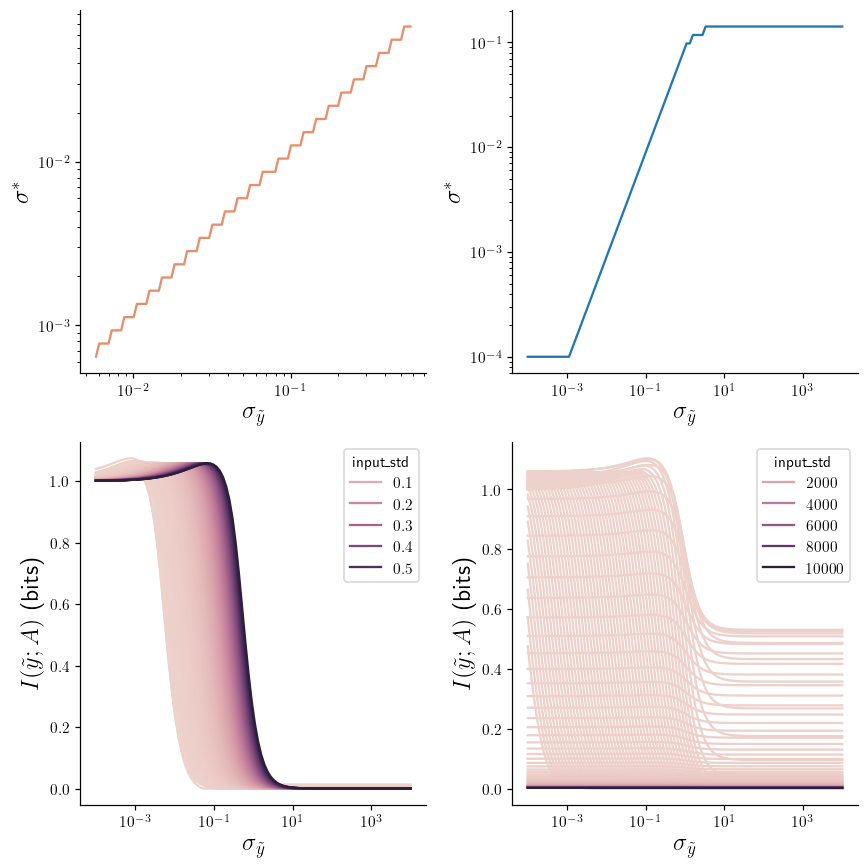

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=110)

flare_pal = sns.color_palette("flare")
# top row: optimal statistics of the noise
ax[0,0].set_xscale("log", base=10)
ax[0,0].set_yscale("log", base=10)
sns.lineplot(data=optimal_uniform, x="input_std", y="optimal_noise", ax=ax[0,0], color=flare_pal[0])
ax[0,1].set_xscale("log", base=10)
ax[0,1].set_yscale("log", base=10)
sns.lineplot(data=optimal_gauss, x="input_std", y="optimal_noise", ax=ax[0,1])

for axs in [ax[0,0], ax[0,1]]:
    axs.set_xlabel(r"$\sigma_{\tilde{y}}$", fontsize=16)
    axs.set_ylabel(r"$\sigma^*$", fontsize=16)
    # axs.tick_params(axis='both', which='major', labelsize=12)
    # axs.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

ax[1,0].set_xscale("log", base=10)
sns.lineplot(data=mi_uniform, x="noise_std", y="mi", ax=ax[1,0], hue="input_std")
ax[1,0].set_ylabel(r"$I(\tilde{y};A)$ (bits)", fontsize=16)
ax[1,0].set_xlabel(r"$\sigma_{\tilde{y}}$", fontsize=16)

ax[1,1].set_xscale("log", base=10)
sns.lineplot(data=mi_gauss, x="noise_std", y="mi", ax=ax[1,1], hue="input_std")
ax[1,1].set_ylabel(r"$I(\tilde{y};A)$ (bits)", fontsize=16)
ax[1,1].set_xlabel(r"$\sigma_{\tilde{y}}$", fontsize=16)

sns.despine()

plt.tight_layout()